In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
train = pd.read_csv("../data_sample/train.csv")
test = pd.read_csv("../data_sample/test.csv")
data = pd.read_csv("../data_sample/Datos.csv")

In [3]:
from utils.funciones import diagramas_barras, diagrama_dispersion, boxplot_histograma, comparar_cualitativas, histograma_por_categorias, \
    get_features_cat_regression, plot_features_cat_regression, plot_features_num_regression

## Exploración inicial

In [4]:
variables = list(set(train.columns) - set(data.columns))
variables

['flag_nuda_propiedad',
 'flag_loft',
 'baños_limpio',
 'tipo_inmueble',
 'flag_subasta',
 'habitaciones_limpio',
 'pct_rebaja',
 'localizacion_limpio',
 'flag_rebaja',
 'barrio',
 'flag_proindiviso',
 'ascensor_limpio',
 'flag_okupada',
 'planta_limpio',
 'flag_alquilada']

In [5]:
target = "PrecioActual"

### Target: PrecioActual

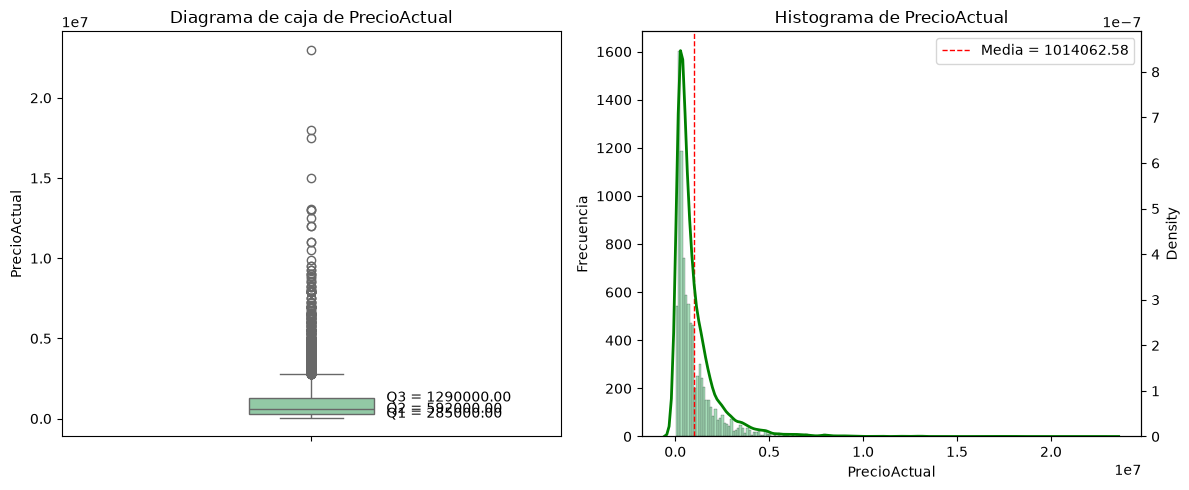

In [6]:
boxplot_histograma(train, target)

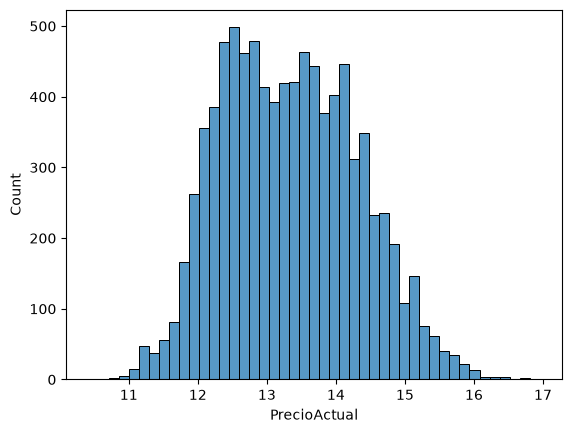

In [7]:
sns.histplot(train[target].transform("log"));

In [8]:
train[target + "_log"] = train[target].transform("log")

In [9]:
new_target = target + "_log"

### Veamos el nº de datos únicos de cada variable

In [10]:
serie_unicos = pd.Series({var:train[var].nunique() for var in variables}, name="nUnique")
serie_unicos.sort_values(ascending=True, inplace=True)
serie_unicos

flag_nuda_propiedad      2
flag_loft                2
flag_subasta             2
flag_rebaja              2
flag_okupada             2
flag_alquilada           2
flag_proindiviso         2
localizacion_limpio      4
ascensor_limpio          4
baños_limpio             7
tipo_inmueble            9
habitaciones_limpio     18
planta_limpio           27
barrio                 139
pct_rebaja             418
Name: nUnique, dtype: int64

Las únicas que podemos considerar numéricas son `habitaciones_limpio`, `planta_limpio` y `pct_rebaja`, pero `planta_limpio` tiene valores cualitativos y `habitaciones_limpio` tiene nans.

#### Habitaciones

In [11]:
scipy.stats.pearsonr(x=train.loc[train.habitaciones_limpio.notna(), "habitaciones_limpio"], y=train.loc[train.habitaciones_limpio.notna(), target])

PearsonRResult(statistic=np.float64(0.5064984785943474), pvalue=np.float64(0.0))

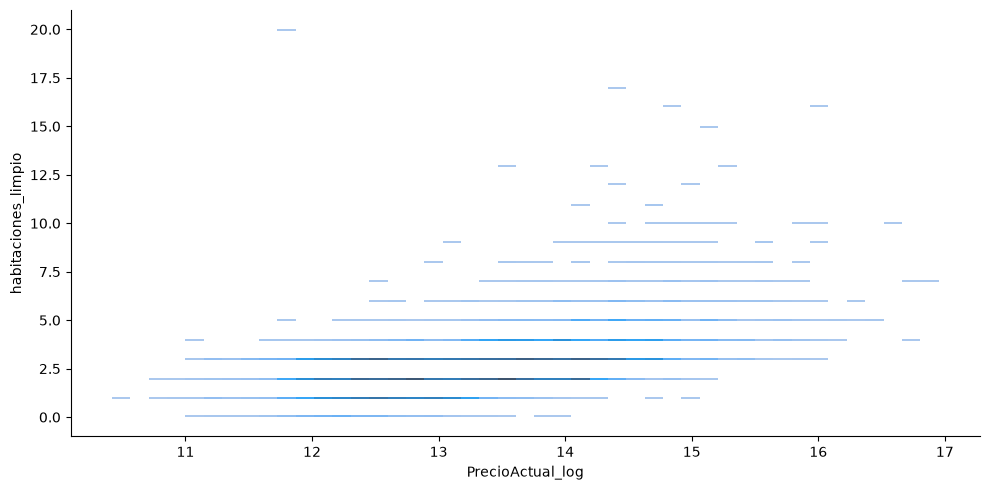

In [12]:
sns.displot(train, x=new_target, y="habitaciones_limpio", aspect=2);

Habitaciones da un coeficiente de pearson con p-valor 0, que es muy extraño. Además hemos tenido que quitar los nans, no tiene buena pinta.

#### Rebaja

In [13]:
train.pct_rebaja.value_counts(True)

pct_rebaja
0.00     0.904661
2.86     0.001453
5.00     0.001453
4.35     0.001341
3.12     0.000894
           ...   
13.33    0.000112
13.09    0.000112
9.96     0.000112
2.46     0.000112
1.17     0.000112
Name: proportion, Length: 418, dtype: float64

Rebaja tiene un 90% de ceros, por lo que tiene mas sentido tratarla como una variable categórica binaria sobre si hay rebaja o no.

In [14]:
train["rebaja"] = (train.pct_rebaja != 0).astype(int)

In [15]:
variables.remove("pct_rebaja")
variables.append("rebaja")

### Análisis de categóricas
Tenemos que quitar las variabels con nulos para poder hacer los estadísticos.

In [16]:
train[variables].info()

<class 'pandas.DataFrame'>
RangeIndex: 8947 entries, 0 to 8946
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   flag_nuda_propiedad  8947 non-null   int64  
 1   flag_loft            8947 non-null   int64  
 2   baños_limpio         1948 non-null   float64
 3   tipo_inmueble        8947 non-null   str    
 4   flag_subasta         8947 non-null   int64  
 5   habitaciones_limpio  8926 non-null   float64
 6   localizacion_limpio  8947 non-null   str    
 7   flag_rebaja          8947 non-null   int64  
 8   barrio               8947 non-null   str    
 9   flag_proindiviso     8947 non-null   int64  
 10  ascensor_limpio      8947 non-null   str    
 11  flag_okupada         8947 non-null   int64  
 12  planta_limpio        8947 non-null   str    
 13  flag_alquilada       8947 non-null   int64  
 14  rebaja               8947 non-null   int64  
dtypes: float64(2), int64(8), str(5)
memory usage: 1.0

In [17]:
vars_sin_nan = variables.copy()
vars_sin_nan.remove("baños_limpio")
vars_sin_nan.remove("habitaciones_limpio")
vars_sin_nan.extend([target, new_target])

In [18]:
vars_significativas = get_features_cat_regression(train[vars_sin_nan], target)    # vars significativas a 0.05
vars_significativas

['flag_nuda_propiedad',
 'flag_loft',
 'tipo_inmueble',
 'flag_subasta',
 'localizacion_limpio',
 'flag_rebaja',
 'flag_proindiviso',
 'ascensor_limpio',
 'flag_okupada',
 'flag_alquilada',
 'rebaja']

In [19]:
# No hay diferencia en las variables significativas con el target transformado
set(vars_significativas)& set(get_features_cat_regression(train[vars_sin_nan], new_target)) == set(vars_significativas)

True

Revisemos ahora las variables con NaNs.
- `baños_limpio`:

In [20]:
grupos = [train.loc[train["baños_limpio"] == clase, target] for clase in train["baños_limpio"].dropna(inplace=False).unique()]
if 1 in [len(grupo) for grupo in grupos]:
    pval_stat = scipy.stats.kruskal(*grupos)[1] # para poblaciones con tamaño muestral pequeño
else:
    pval_stat = scipy.stats.f_oneway(*grupos)[1]

pval_stat

np.float64(1.0663130348902189e-138)

In [21]:
vars_significativas.append("baños_limpio")

In [22]:
# Veamos si hay alguna diferencia con el target transformado
grupos = [train.loc[train["baños_limpio"] == clase, new_target] for clase in train["baños_limpio"].dropna(inplace=False).unique()]
if 1 in [len(grupo) for grupo in grupos]:
    pval_stat = scipy.stats.kruskal(*grupos)[1] # para poblaciones con tamaño muestral pequeño
else:
    pval_stat = scipy.stats.f_oneway(*grupos)[1]

pval_stat   # es aun más significativa

np.float64(1.0808029532200806e-163)

- `habitaciones_limpio`, esta vez incluyendo los nulos:

In [23]:
grupos = [train.loc[train["habitaciones_limpio"] == clase, target] for clase in train["habitaciones_limpio"].dropna(inplace=False).unique()]
if 1 in [len(grupo) for grupo in grupos]:
    pval_stat = scipy.stats.kruskal(*grupos)[1] # para poblaciones con tamaño muestral pequeño
else:
    pval_stat = scipy.stats.f_oneway(*grupos)[1]

pval_stat

np.float64(0.0)

In [24]:
grupos = [train.loc[train["habitaciones_limpio"] == clase, new_target] for clase in train["habitaciones_limpio"].dropna(inplace=False).unique()]
if 1 in [len(grupo) for grupo in grupos]:
    pval_stat = scipy.stats.kruskal(*grupos)[1] # para poblaciones con tamaño muestral pequeño
else:
    pval_stat = scipy.stats.f_oneway(*grupos)[1]

pval_stat

np.float64(0.0)

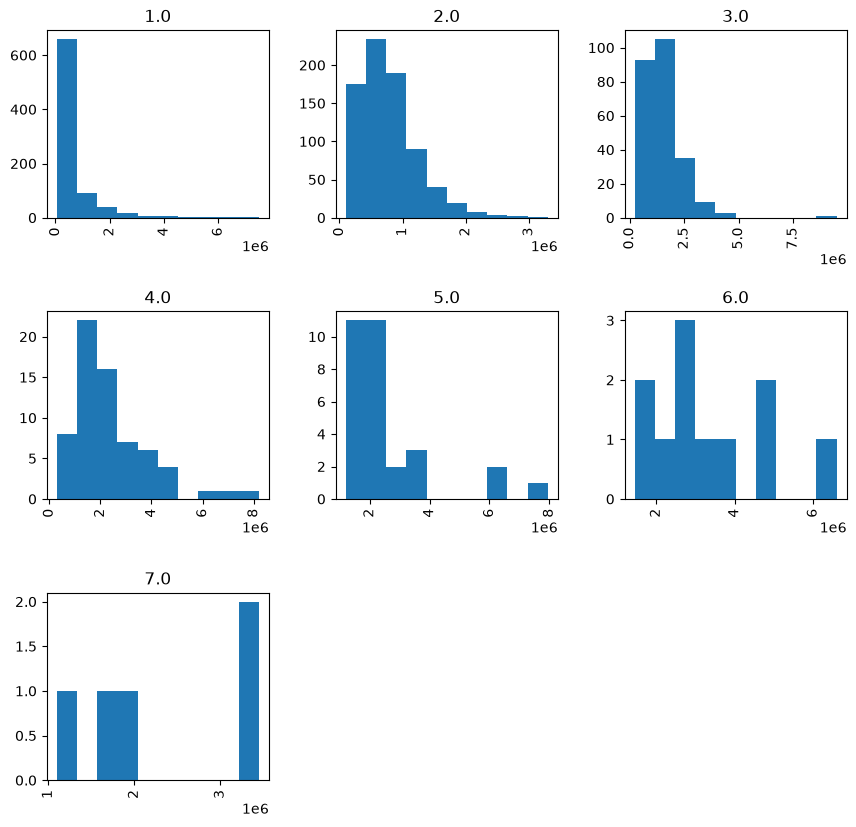

In [25]:
train.hist(column=target, by="baños_limpio", figsize=(10, 10));

## Features seleccionadas

In [26]:
vars_significativas.append("habitaciones_limpio")
vars_significativas

['flag_nuda_propiedad',
 'flag_loft',
 'tipo_inmueble',
 'flag_subasta',
 'localizacion_limpio',
 'flag_rebaja',
 'flag_proindiviso',
 'ascensor_limpio',
 'flag_okupada',
 'flag_alquilada',
 'rebaja',
 'baños_limpio',
 'habitaciones_limpio']

In [27]:
len(vars_significativas)

13

In [28]:
set(variables)-set(vars_significativas)

{'barrio', 'planta_limpio'}

Barrio se puede incluir en un Catboost a ver si puede mejorar el modelo.

## Interacciones entre variables

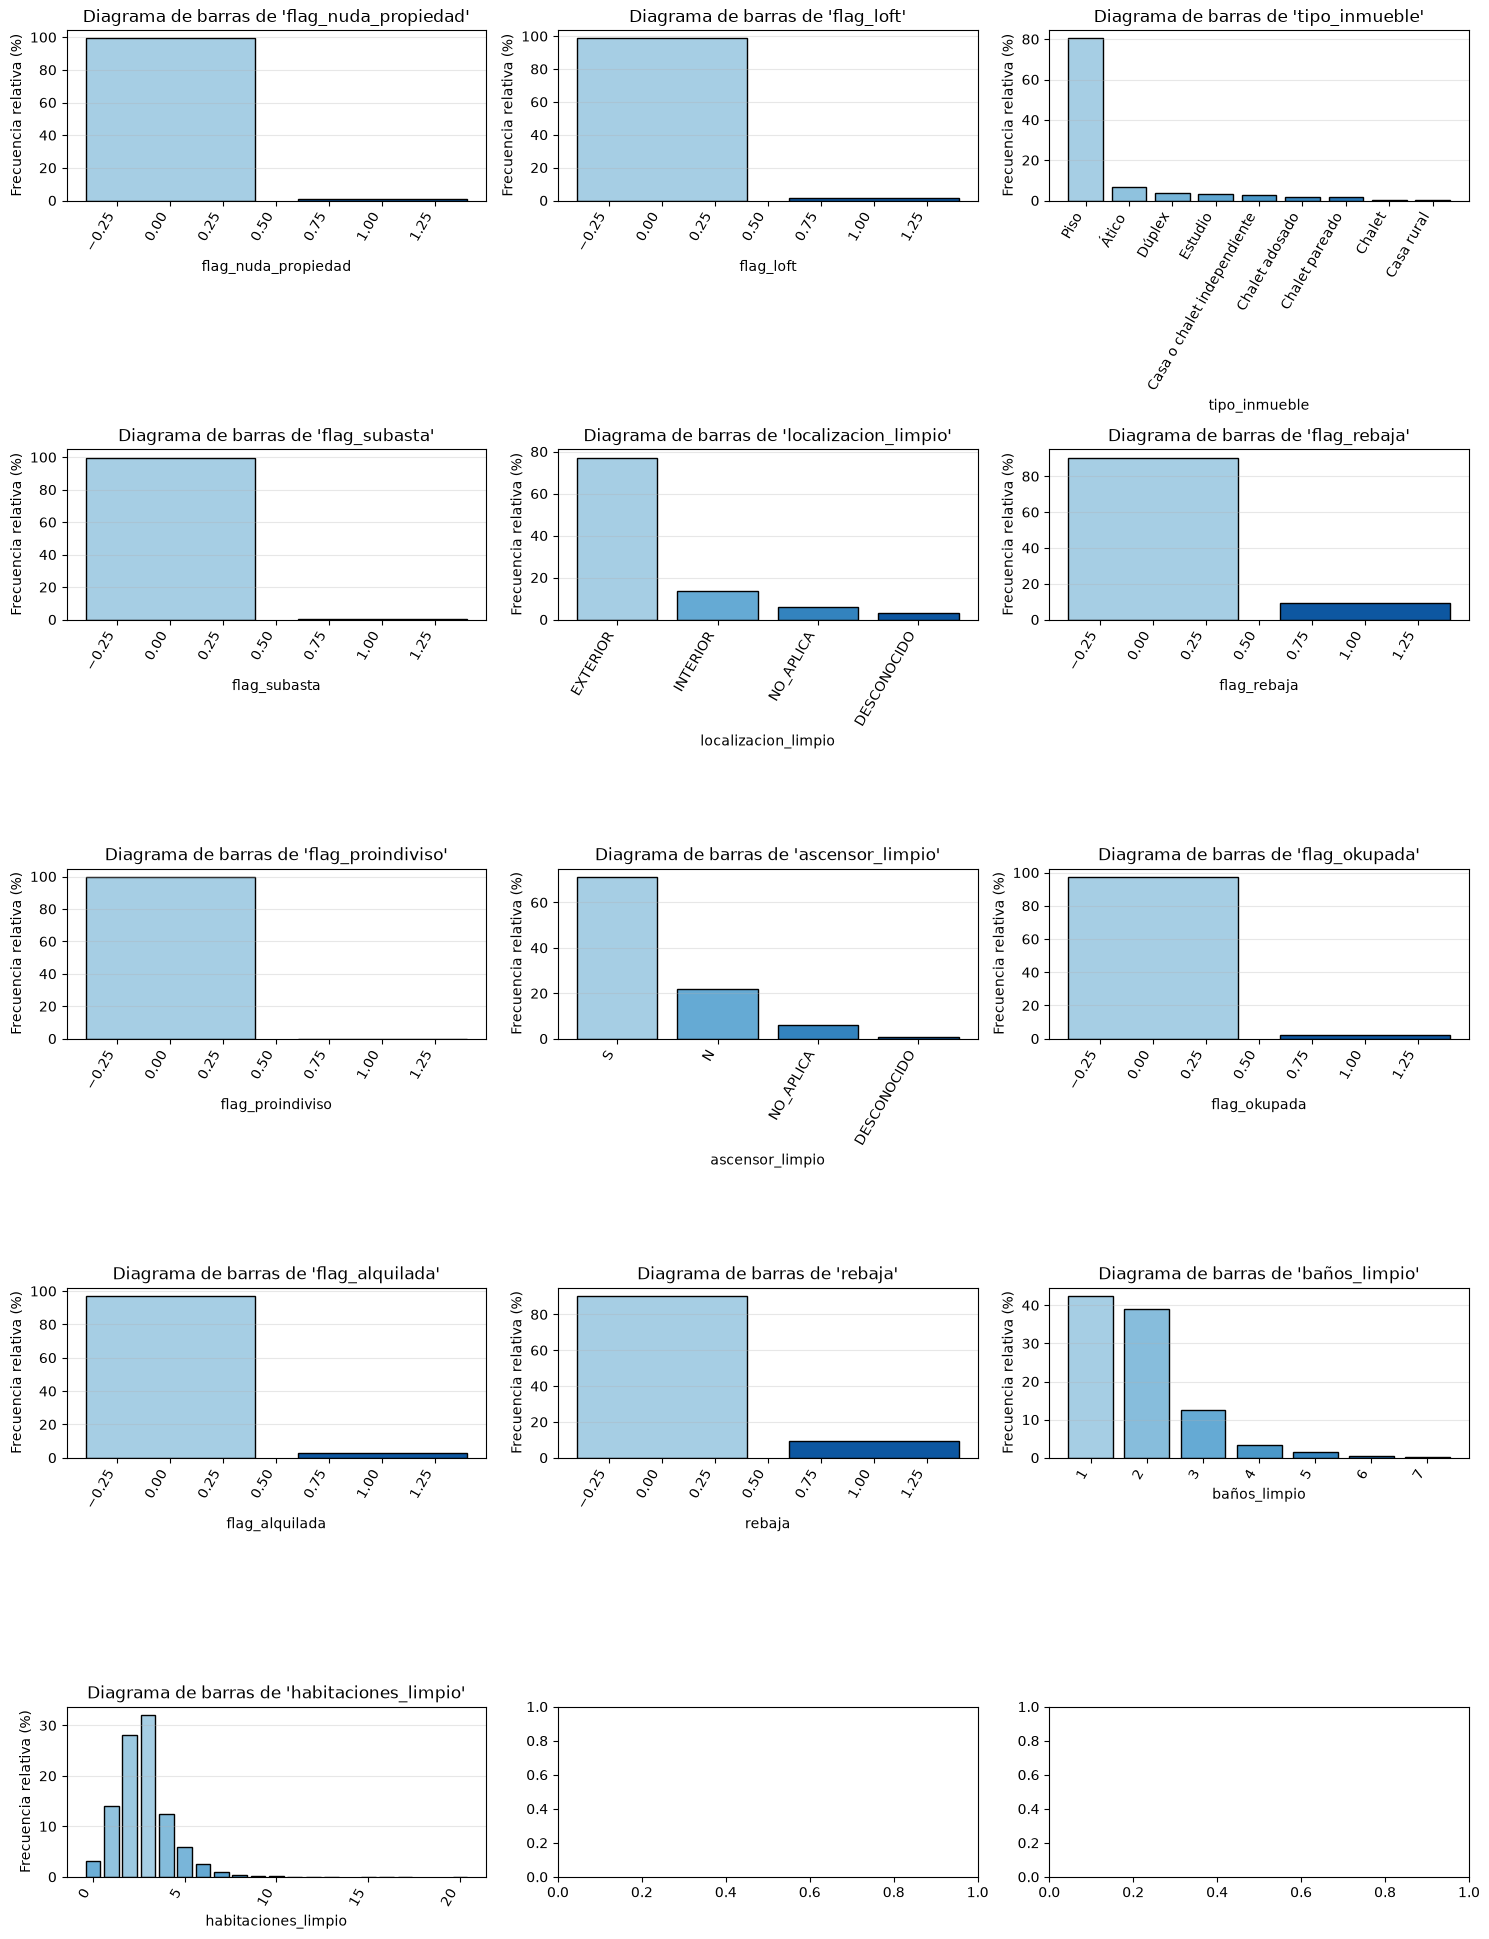

In [31]:
diagramas_barras(train, vars_significativas, relativo=True)

#### Relación con `habitaciones_limpio`

In [ ]:
relaciones = pd.DataFrame(np.zeros((len(vars_significativas), len(vars_significativas))), columns=vars_significativas, index=vars_significativas)

In [47]:
for var in vars_significativas:
    if var != "habitaciones_limpio":
        clases = [clase for clase in train.loc[train[var].notna(), var].unique()]
        grupos = [train.loc[(train[var] == clase)&(train.habitaciones_limpio.notna()), "habitaciones_limpio"] for clase in clases]
        print(f"ANOVA para las poblaciones de habitaciones_limpio según {var}:")
        stat, pval = scipy.stats.f_oneway(*grupos)
        print(stat, pval)
        if pval <= 0.05:
            relaciones.loc[var,"habitaciones_limpio"] = 1
            relaciones.loc["habitaciones_limpio", var] = 1
        print()

ANOVA para las poblaciones de habitaciones_limpio según flag_nuda_propiedad:
0.035571091951836324 0.8504082692725041

ANOVA para las poblaciones de habitaciones_limpio según flag_loft:
107.13184213958762 5.764257369395032e-25

ANOVA para las poblaciones de habitaciones_limpio según tipo_inmueble:
470.62283115543397 0.0

ANOVA para las poblaciones de habitaciones_limpio según flag_subasta:
0.10586423675225229 0.744910313956061

ANOVA para las poblaciones de habitaciones_limpio según localizacion_limpio:
871.756774921195 0.0

ANOVA para las poblaciones de habitaciones_limpio según flag_rebaja:
3.2851514681706995 0.06994276743694848

ANOVA para las poblaciones de habitaciones_limpio según flag_proindiviso:
0.060577116168694996 0.805591759701687

ANOVA para las poblaciones de habitaciones_limpio según ascensor_limpio:
778.6312958248643 0.0

ANOVA para las poblaciones de habitaciones_limpio según flag_okupada:
12.85402451752594 0.0003385528849977091

ANOVA para las poblaciones de habitacion

### Variables cualitativas

In [51]:
from scipy.stats import chi2_contingency
for i in range(len(vars_significativas)):
    for j in range(i+1, len(vars_significativas)):
        if (vars_significativas[i]!="habitaciones_limpio") & (vars_significativas[j]!="habitaciones_limpio"):
            var1 = vars_significativas[i]
            var2 = vars_significativas[j]
            tabla_contingencia = pd.crosstab(train[var1], train[var2])

            chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
            print(f"TEST CHI CUADRADO: {var1} - {var2}")
            print("Valor Chi-Cuadrado:", chi2)
            print("P-Value:", p)
            print()

            if p <= 0.05:
                relaciones.loc[var1,var2] = 1
                relaciones.loc[var2, var1] = 1

TEST CHI CUADRADO: flag_nuda_propiedad - flag_loft
Valor Chi-Cuadrado: 0.20757537200605708
P-Value: 0.6486744764106407

TEST CHI CUADRADO: flag_nuda_propiedad - tipo_inmueble
Valor Chi-Cuadrado: 6.6777975243936405
P-Value: 0.5717607724182028

TEST CHI CUADRADO: flag_nuda_propiedad - flag_subasta
Valor Chi-Cuadrado: 0.0
P-Value: 1.0

TEST CHI CUADRADO: flag_nuda_propiedad - localizacion_limpio
Valor Chi-Cuadrado: 5.9463878212193135
P-Value: 0.11424790771089383

TEST CHI CUADRADO: flag_nuda_propiedad - flag_rebaja
Valor Chi-Cuadrado: 0.7779149316614775
P-Value: 0.3777795872863553

TEST CHI CUADRADO: flag_nuda_propiedad - flag_proindiviso
Valor Chi-Cuadrado: 0.0
P-Value: 1.0

TEST CHI CUADRADO: flag_nuda_propiedad - ascensor_limpio
Valor Chi-Cuadrado: 5.671310765332763
P-Value: 0.1287439067303157

TEST CHI CUADRADO: flag_nuda_propiedad - flag_okupada
Valor Chi-Cuadrado: 0.7971529018340121
P-Value: 0.3719459706171657

TEST CHI CUADRADO: flag_nuda_propiedad - flag_alquilada
Valor Chi-Cuadra

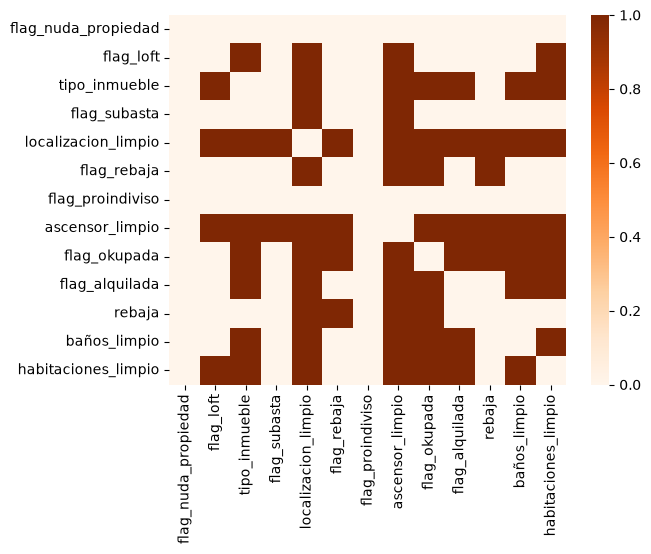

In [53]:
sns.heatmap(relaciones, cmap="Oranges");

Ascensor tiene muchas relaciones significativas de dependencia con otras variables. A lo mejor hay que quitarla, dependiendo de cómo funcione dentro del modelo.